# 07 Missing Data and Feature Selection

Missing-data diagnosis, leakage-safe imputation, feature screening, and experiment dataset creation.

,split,rows,stations,start_year,end_year
0,test,72,6,2022,2022
1,train,288,6,2017,2020
2,validation,72,6,2021,2021


,Feature,Missing_Count,Missing_Percent,Valid_Count,Unique_Values
0,CCS,72,16.6667,360,313
1,CDR,72,16.6667,360,347
2,CHIRPS,0,0.0000,432,432
3,ERA5,0,0.0000,432,432
4,GSMaP_Gauge,0,0.0000,432,412
5,GSMaP_MVK,18,4.1667,414,407
6,IMERG,0,0.0000,432,414
7,LST,47,10.8796,385,356
8,NDVI,0,0.0000,432,404
9,PDIR,72,16.6667,360,343


,Feature,Unique_Values,Dominant_Ratio,Constant,Near_Constant
0,CCS,212,0.075000,False,False
1,CDR,231,0.041667,False,False
2,CHIRPS,288,0.003472,False,False
3,ERA5,288,0.003472,False,False
4,GSMaP_Gauge,270,0.065972,False,False
5,GSMaP_MVK,269,0.028986,False,False
6,IMERG,279,0.017361,False,False
7,LST,248,0.011450,False,False
8,NDVI,273,0.006944,False,False
9,PDIR,229,0.045833,False,False


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,CDR,IMERG,0.964480,0.964480
1,CHIRPS,IMERG,0.960869,0.960869
2,CDR,CHIRPS,0.956981,0.956981
3,CCS,PDIR,0.953665,0.953665
4,GSMaP_Gauge,IMERG,0.937700,0.937700
5,Distance_Sea_meter,latitude,0.937196,0.937196
6,CDR,ERA5,0.933953,0.933953
7,ERA5,IMERG,0.930150,0.930150
8,CCS,CDR,0.908602,0.908602
9,CHIRPS,GSMaP_Gauge,0.906383,0.906383


,Experiment,Rows,Feature_Count,Missing_Feature_Values
0,A_complete_case,248,19,0
1,B_hierarchical_imputation,432,19,0
2,C_reduced_features,372,15,0
3,D_without_GSMaP_Gauge,432,18,0


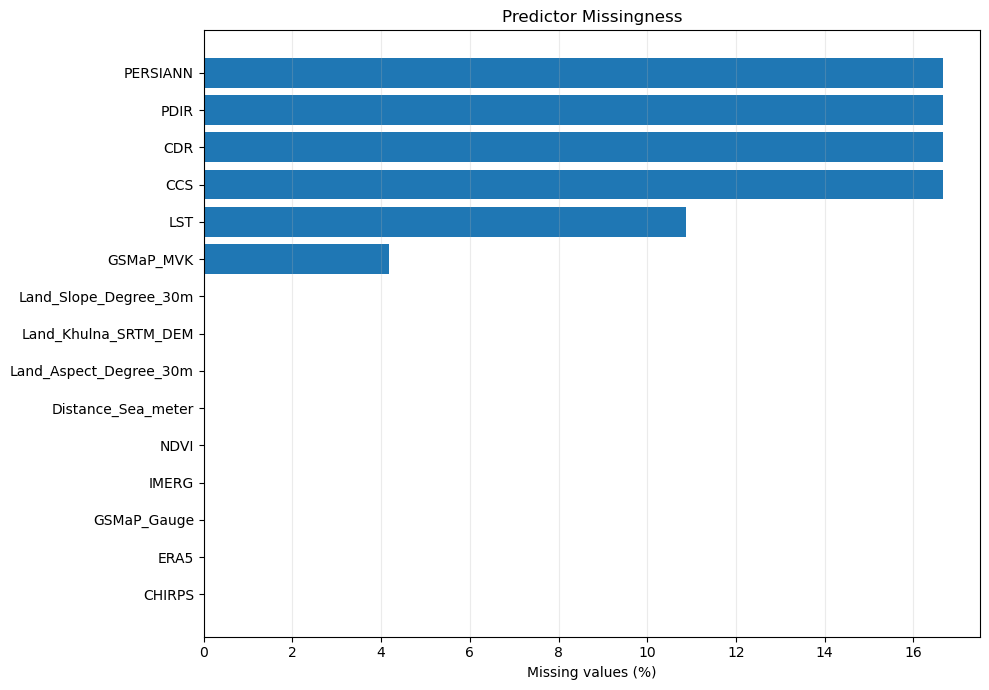

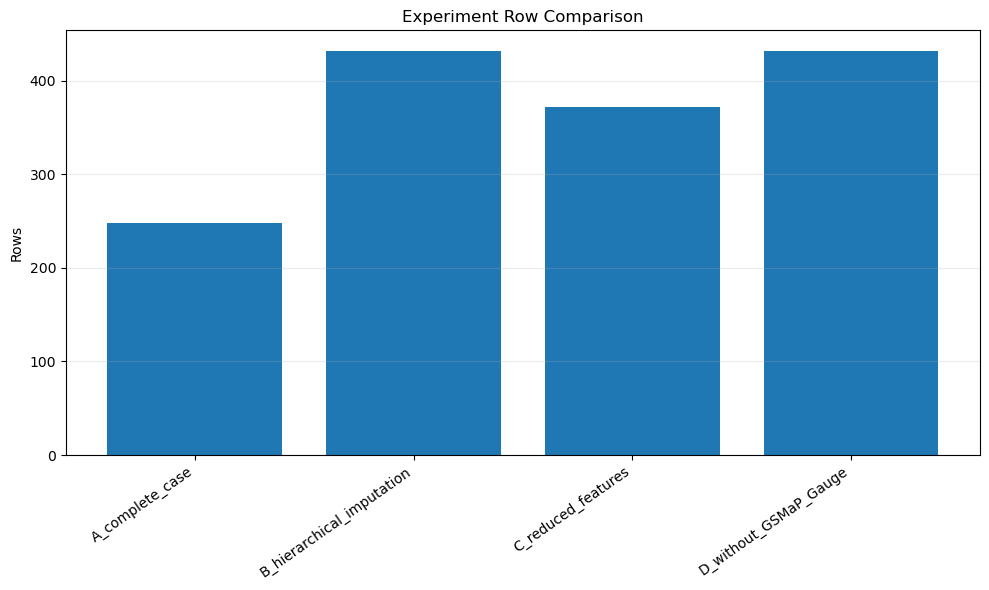

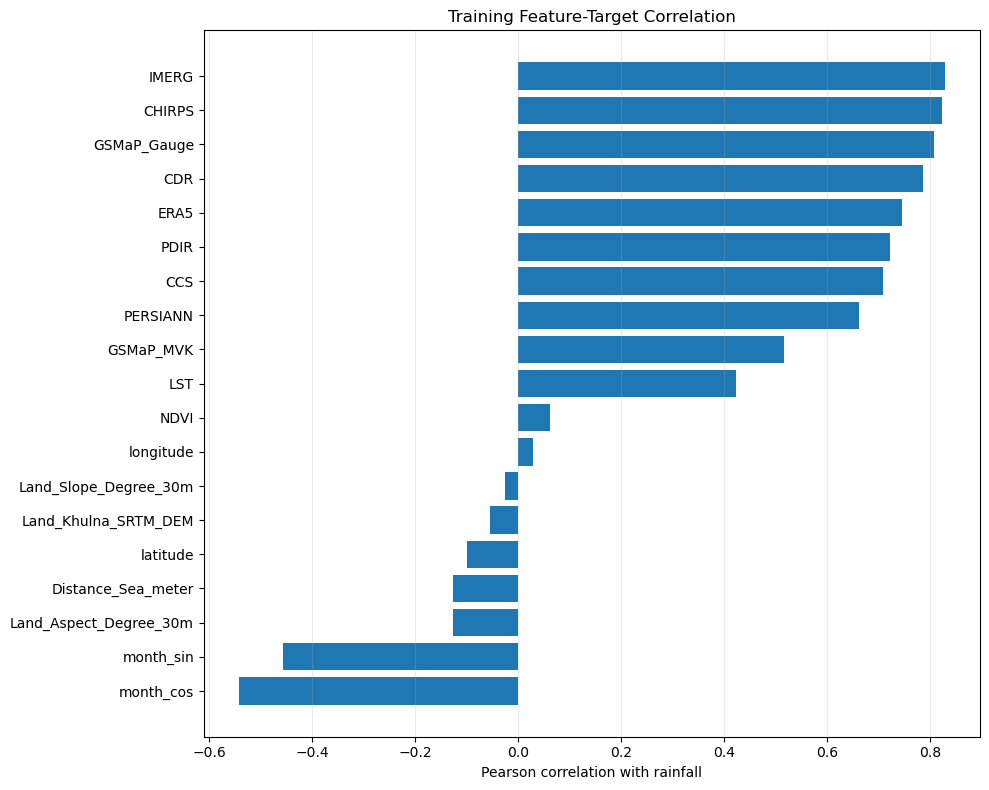


MISSING DATA AND FEATURE SELECTION COMPLETED
Input rows               : 432
Train rows               : 288
Validation rows          : 72
Test rows                : 72
Complete-case rows       : 248
Imputed rows             : 432
Reduced-feature rows     : 372
Base feature count       : 19
Reduced feature count    : 15
Missing after imputation : 0
Recommended dataset      : E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna\data\processed\model_data\feature_selection\recommended_training_dataset.csv


In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(r'E:\Geospatial\Precipitation Downscaling\Precipitation-Downscaling-Khulna')
INPUT_CSV = PROJECT_ROOT / 'data' / 'processed' / 'model_data' / 'model_dataset_eda_ready.csv'
OUTPUT_FOLDER = PROJECT_ROOT / 'data' / 'processed' / 'model_data' / 'feature_selection'
LOG_FOLDER = PROJECT_ROOT / 'data' / 'processed' / 'logs'
FIGURE_FOLDER = PROJECT_ROOT / 'figures' / 'feature_selection'
for p in [OUTPUT_FOLDER, LOG_FOLDER, FIGURE_FOLDER]: p.mkdir(parents=True, exist_ok=True)

TARGET = 'rainfall_mm'
TRAIN_YEARS = [2017, 2018, 2019, 2020]
VALIDATION_YEARS = [2021]
TEST_YEARS = [2022]
PREDICTORS = ['CCS','CDR','CHIRPS','ERA5','GSMaP_Gauge','GSMaP_MVK','IMERG','LST','NDVI','PDIR','PERSIANN','Distance_Sea_meter','Land_Aspect_Degree_30m','Land_Khulna_SRTM_DEM','Land_Slope_Degree_30m']
TEMPORAL = ['month_sin','month_cos']
COORDINATES = ['latitude','longitude']
MANUAL_REDUCED_EXCLUSIONS = ['CCS','CDR','PDIR','PERSIANN']
HIGH_CORR = 0.90

def split_name(year):
    if year in TRAIN_YEARS: return 'train'
    if year in VALIDATION_YEARS: return 'validation'
    if year in TEST_YEARS: return 'test'
    return 'unused'

def save_fig(name):
    path = FIGURE_FOLDER / name
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.show(); plt.close()
    return path

def missing_summary(data, features):
    rows=[]
    for f in features:
        if f not in data.columns: continue
        m=int(data[f].isna().sum()); p=m/len(data)*100
        rows.append({'Feature':f,'Missing_Count':m,'Missing_Percent':round(p,4),'Valid_Count':int(data[f].notna().sum()),'Unique_Values':int(data[f].nunique(dropna=True))})
    return pd.DataFrame(rows)

def constant_summary(data, features):
    rows=[]
    for f in features:
        s=data[f].dropna(); u=int(s.nunique())
        dr=float(s.value_counts(normalize=True).iloc[0]) if len(s) else np.nan
        rows.append({'Feature':f,'Unique_Values':u,'Dominant_Ratio':dr,'Constant':u<=1,'Near_Constant':(u<=1) or (pd.notna(dr) and dr>=0.95)})
    return pd.DataFrame(rows)

def high_corr_pairs(data, features, threshold=0.90):
    features=[f for f in features if f in data.columns and data[f].nunique(dropna=True)>1]
    corr=data[features].corr(); rows=[]
    for i,a in enumerate(features):
        for b in features[i+1:]:
            r=corr.loc[a,b]
            if pd.notna(r) and abs(r)>=threshold: rows.append({'Feature_1':a,'Feature_2':b,'Correlation':float(r),'Absolute_Correlation':float(abs(r))})
    return pd.DataFrame(rows).sort_values('Absolute_Correlation',ascending=False).reset_index(drop=True) if rows else pd.DataFrame(columns=['Feature_1','Feature_2','Correlation','Absolute_Correlation'])

def fit_imputer(train, features):
    return {
      'station_month': {f: train.groupby(['station_id','month'])[f].median() for f in features},
      'month': {f: train.groupby('month')[f].median() for f in features},
      'global': {f: train[f].median() for f in features}
    }

def apply_imputer(data, features, imp, split):
    out=data.copy(); audit=[]
    for f in features:
        original=int(out[f].isna().sum()); c1=c2=c3=0
        sm=imp['station_month'][f]
        for idx in out.index[out[f].isna()]:
            key=(out.at[idx,'station_id'],out.at[idx,'month'])
            if key in sm.index and pd.notna(sm.loc[key]): out.at[idx,f]=sm.loc[key]; c1+=1
        mm=imp['month'][f]
        for idx in out.index[out[f].isna()]:
            m=out.at[idx,'month']
            if m in mm.index and pd.notna(mm.loc[m]): out.at[idx,f]=mm.loc[m]; c2+=1
        mask=out[f].isna(); c3=int(mask.sum())
        if pd.notna(imp['global'][f]): out.loc[mask,f]=imp['global'][f]
        audit.append({'Split':split,'Feature':f,'Original_Missing':original,'Filled_Station_Month':c1,'Filled_Calendar_Month':c2,'Filled_Global_Median':c3,'Remaining_Missing':int(out[f].isna().sum())})
    return out,pd.DataFrame(audit)

if not INPUT_CSV.exists(): raise FileNotFoundError(f'Input dataset not found: {INPUT_CSV}')
df=pd.read_csv(INPUT_CSV)
if 'date' in df.columns: df['date']=pd.to_datetime(df['date'],errors='coerce')
for c in PREDICTORS+TEMPORAL+COORDINATES+[TARGET,'year','month']:
    if c in df.columns: df[c]=pd.to_numeric(df[c],errors='coerce')
df['year']=df['year'].astype(int); df['month']=df['month'].astype(int); df['split']=df['year'].apply(split_name)
df=df[df['split']!='unused'].copy()
available=[f for f in PREDICTORS if f in df.columns]
candidates=available+[f for f in TEMPORAL+COORDINATES if f in df.columns]
dup=int(df.duplicated(['station_id','year','month']).sum())
if dup: raise ValueError(f'{dup} duplicate station-month rows found')

split_summary=df.groupby('split',as_index=False).agg(rows=(TARGET,'size'),stations=('station_id','nunique'),start_year=('year','min'),end_year=('year','max'))
display(split_summary)

miss=missing_summary(df,available); display(miss)
miss_station=df.groupby(['station_id','station_name'])[available].agg(lambda s:int(s.isna().sum())).reset_index()
miss_ym=df.groupby(['year','month'])[available].agg(lambda s:int(s.isna().sum())).reset_index()
miss_month=df.groupby('month')[available].agg(lambda s:int(s.isna().sum())).reset_index()
miss_split=df.groupby('split')[available].agg(lambda s:int(s.isna().sum())).reset_index()

train=df[df['split']=='train'].copy(); val=df[df['split']=='validation'].copy(); test=df[df['split']=='test'].copy()
const=constant_summary(train,candidates); display(const)
constant_features=const.loc[const['Constant'],'Feature'].tolist()
base=[f for f in candidates if f not in constant_features]
corr_pairs=high_corr_pairs(train,base,HIGH_CORR); display(corr_pairs)

complete=df.dropna(subset=base+[TARGET]).copy()
imp=fit_imputer(train,base)
train_i,a1=apply_imputer(train,base,imp,'train')
val_i,a2=apply_imputer(val,base,imp,'validation')
test_i,a3=apply_imputer(test,base,imp,'test')
imputed=pd.concat([train_i,val_i,test_i],ignore_index=True).sort_values(['year','month','station_id']).reset_index(drop=True)
audit=pd.concat([a1,a2,a3],ignore_index=True)
remaining=int(imputed[base].isna().sum().sum())
if remaining: raise RuntimeError(f'{remaining} feature values remain missing after imputation')

reduced=[f for f in base if f not in MANUAL_REDUCED_EXCLUSIONS]
reduced_df=df.dropna(subset=reduced+[TARGET]).copy().sort_values(['year','month','station_id']).reset_index(drop=True)
without_gauge=[f for f in base if f!='GSMaP_Gauge']

target_corr=[]
for f in base:
    pear=train_i[[f,TARGET]].corr(method='pearson').iloc[0,1]
    spear=train_i[[f,TARGET]].corr(method='spearman').iloc[0,1]
    target_corr.append({'Feature':f,'Pearson_Correlation':pear,'Spearman_Correlation':spear,'Absolute_Pearson':abs(pear) if pd.notna(pear) else np.nan})
target_corr=pd.DataFrame(target_corr).sort_values('Absolute_Pearson',ascending=False).reset_index(drop=True)

exp=pd.DataFrame([
 {'Experiment':'A_complete_case','Rows':len(complete),'Feature_Count':len(base),'Missing_Feature_Values':int(complete[base].isna().sum().sum())},
 {'Experiment':'B_hierarchical_imputation','Rows':len(imputed),'Feature_Count':len(base),'Missing_Feature_Values':int(imputed[base].isna().sum().sum())},
 {'Experiment':'C_reduced_features','Rows':len(reduced_df),'Feature_Count':len(reduced),'Missing_Feature_Values':int(reduced_df[reduced].isna().sum().sum())},
 {'Experiment':'D_without_GSMaP_Gauge','Rows':len(imputed),'Feature_Count':len(without_gauge),'Missing_Feature_Values':int(imputed[without_gauge].isna().sum().sum())}
])
display(exp)

plt.figure(figsize=(10,7)); p=miss.sort_values('Missing_Percent'); plt.barh(p['Feature'],p['Missing_Percent']); plt.xlabel('Missing values (%)'); plt.title('Predictor Missingness'); plt.grid(axis='x',alpha=.25); save_fig('01_predictor_missingness.png')
plt.figure(figsize=(10,6)); plt.bar(exp['Experiment'],exp['Rows']); plt.xticks(rotation=35,ha='right'); plt.ylabel('Rows'); plt.title('Experiment Row Comparison'); plt.grid(axis='y',alpha=.25); save_fig('02_experiment_rows.png')
plt.figure(figsize=(10,8)); q=target_corr.sort_values('Pearson_Correlation'); plt.barh(q['Feature'],q['Pearson_Correlation']); plt.xlabel('Pearson correlation with rainfall'); plt.title('Training Feature-Target Correlation'); plt.grid(axis='x',alpha=.25); save_fig('03_target_correlation.png')

complete.to_csv(OUTPUT_FOLDER/'experiment_A_complete_case.csv',index=False)
imputed.to_csv(OUTPUT_FOLDER/'experiment_B_hierarchical_imputation.csv',index=False)
reduced_df.to_csv(OUTPUT_FOLDER/'experiment_C_reduced_features.csv',index=False)
imputed.to_csv(OUTPUT_FOLDER/'experiment_D_without_GSMaP_Gauge.csv',index=False)
imputed.to_csv(OUTPUT_FOLDER/'recommended_training_dataset.csv',index=False)
miss.to_csv(LOG_FOLDER/'feature_selection_missing_summary.csv',index=False)
miss_station.to_csv(LOG_FOLDER/'feature_selection_missing_by_station.csv',index=False)
miss_ym.to_csv(LOG_FOLDER/'feature_selection_missing_by_year_month.csv',index=False)
miss_month.to_csv(LOG_FOLDER/'feature_selection_missing_by_calendar_month.csv',index=False)
miss_split.to_csv(LOG_FOLDER/'feature_selection_missing_by_split.csv',index=False)
const.to_csv(LOG_FOLDER/'feature_selection_constant_summary.csv',index=False)
corr_pairs.to_csv(LOG_FOLDER/'feature_selection_high_correlation_pairs.csv',index=False)
audit.to_csv(LOG_FOLDER/'feature_selection_imputation_audit.csv',index=False)
target_corr.to_csv(LOG_FOLDER/'feature_selection_target_correlation.csv',index=False)
exp.to_csv(LOG_FOLDER/'feature_selection_experiment_summary.csv',index=False)
split_summary.to_csv(LOG_FOLDER/'feature_selection_split_summary.csv',index=False)
feature_sets={'base_features':base,'reduced_features':reduced,'without_gsmap_gauge_features':without_gauge,'constant_features_removed':constant_features}
with open(LOG_FOLDER/'feature_selection_feature_sets.json','w',encoding='utf-8') as f: json.dump(feature_sets,f,indent=2,ensure_ascii=False)

print('\n'+'='*86)
print('MISSING DATA AND FEATURE SELECTION COMPLETED')
print('='*86)
print(f'Input rows               : {len(df)}')
print(f'Train rows               : {len(train)}')
print(f'Validation rows          : {len(val)}')
print(f'Test rows                : {len(test)}')
print(f'Complete-case rows       : {len(complete)}')
print(f'Imputed rows             : {len(imputed)}')
print(f'Reduced-feature rows     : {len(reduced_df)}')
print(f'Base feature count       : {len(base)}')
print(f'Reduced feature count    : {len(reduced)}')
print(f'Missing after imputation : {remaining}')
print('Recommended dataset      :', OUTPUT_FOLDER / 'recommended_training_dataset.csv')
